<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [12]</a>'.</span>

# EcoSortAI: Smart Waste Classification with Deployment-Aware Deep Learning

> **Task:** Multi-class image classification of waste into 10 fine-grained categories to support smart, automated recycling systems.

This project goes beyond simple accuracy benchmarking. It is designed as a **deployment-aware** system that considers:
- Which model fits on an edge device (smart bin, Raspberry Pi, phone)?
- Which model maximises accuracy for a server-side API?
- How can the model also recommend the correct disposal bin?
- How confident is the model, and when should it ask for human review?

---

## The Six-Model Strategy

| Model | Role | Deployment Target |
|---|---|---|
| **SimpleCNN** | Custom baseline (no pretraining) | Educational |
| **MobileNetV3-Small** | Lightweight transfer learning | Smart bin / Mobile app / Edge |
| **ResNet50** | Strong classical CNN benchmark | Server reference |
| **EfficientNet-B0** | Best single-model performance | Cloud API / Server |
| **EfficientNet + ResNet Ensemble** | Accuracy-focused combined model | Server-side batch |
| **Multi-task EfficientNet** | Predicts class + disposal bin | Smart recycling assistant |

---

## Dataset

- **Source:** `sumn2u/garbage-classification-v2` (KaggleHub)
- **Folder used:** `standardized_256/` only (leakage-free)
- **Total images:** ~12,259  **Classes:** 10
- **Split:** 70% train / 15% validation / 15% test

> **Data Leakage Note:** The dataset ships with three image sets (`original`, `standardized_256`, `standardized_384`).
> Loading all three inflates the dataset to ~36,777 images and causes severe leakage.
> This notebook uses **only `standardized_256`** to prevent this.

---
## Section 1 - Dataset Download & Loading

We download the dataset with KaggleHub and load image paths from **`standardized_256` only**.
Labels come from the parent folder name of each image file.

In [ ]:
import kagglehub
from pathlib import Path
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print(f"Dataset downloaded to: {path}")

# Use ONLY standardized_256 to prevent data leakage
dataset_path = Path(path) / "standardized_256"
print(f"Loading images from: {dataset_path}")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []
missing  = 0
for label_dir in sorted(dataset_path.iterdir()):
    if label_dir.is_dir():
        for img_file in label_dir.iterdir():
            if img_file.suffix.lower() in image_extensions:
                # Skip corrupted or missing files from the Kaggle cache
                if img_file.exists() and img_file.stat().st_size > 0:
                    records.append({"image_path": str(img_file), "label": label_dir.name})
                else:
                    missing += 1

if missing:
    print(f"Warning: skipped {missing} missing/empty file(s) in dataset cache.")

data = pd.DataFrame(records)
classes     = sorted(data["label"].unique())
num_classes = len(classes)
print(f"\nTotal images : {len(data)}")
print(f"Num classes  : {num_classes}")
print(f"Classes      : {classes}")
print(f"\nClass distribution:")
print(data["label"].value_counts().to_string())


---
## Section 2 - Exploratory Data Analysis

### Class Imbalance

The dataset is **moderately imbalanced**:
- **Larger classes:** `clothes`, `glass`, `plastic` -- well represented
- **Smaller classes:** `trash`, `biological`, `battery` -- underrepresented

This matters because:
1. Accuracy is dominated by majority classes.
2. **Macro F1** treats all classes equally and is a fairer metric for imbalanced data.
3. **Class-weighted loss** compensates during training by penalising errors on rare classes more heavily.

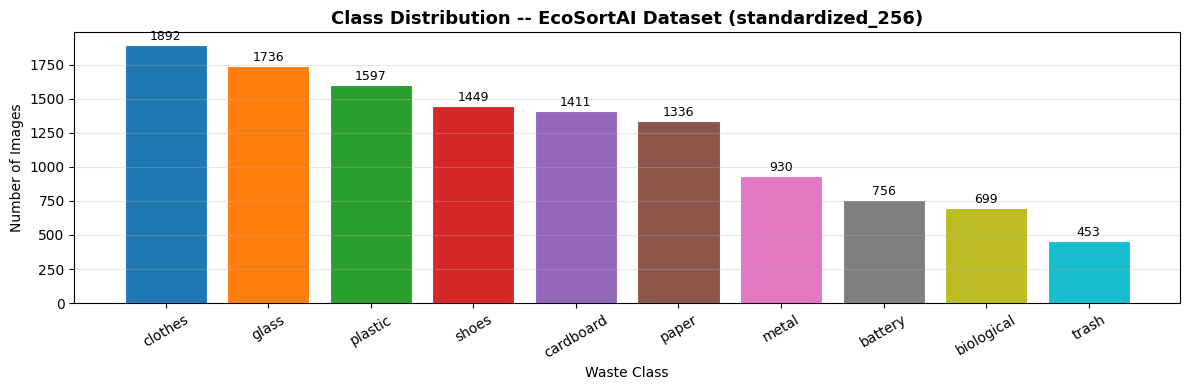

In [2]:
import matplotlib.pyplot as plt
import numpy as np

class_dist = data["label"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(class_dist)))
bars = ax.bar(class_dist.index, class_dist.values, color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, class_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            str(val), ha="center", va="bottom", fontsize=9)

ax.set_title("Class Distribution -- EcoSortAI Dataset (standardized_256)", fontweight="bold", fontsize=13)
ax.set_xlabel("Waste Class")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

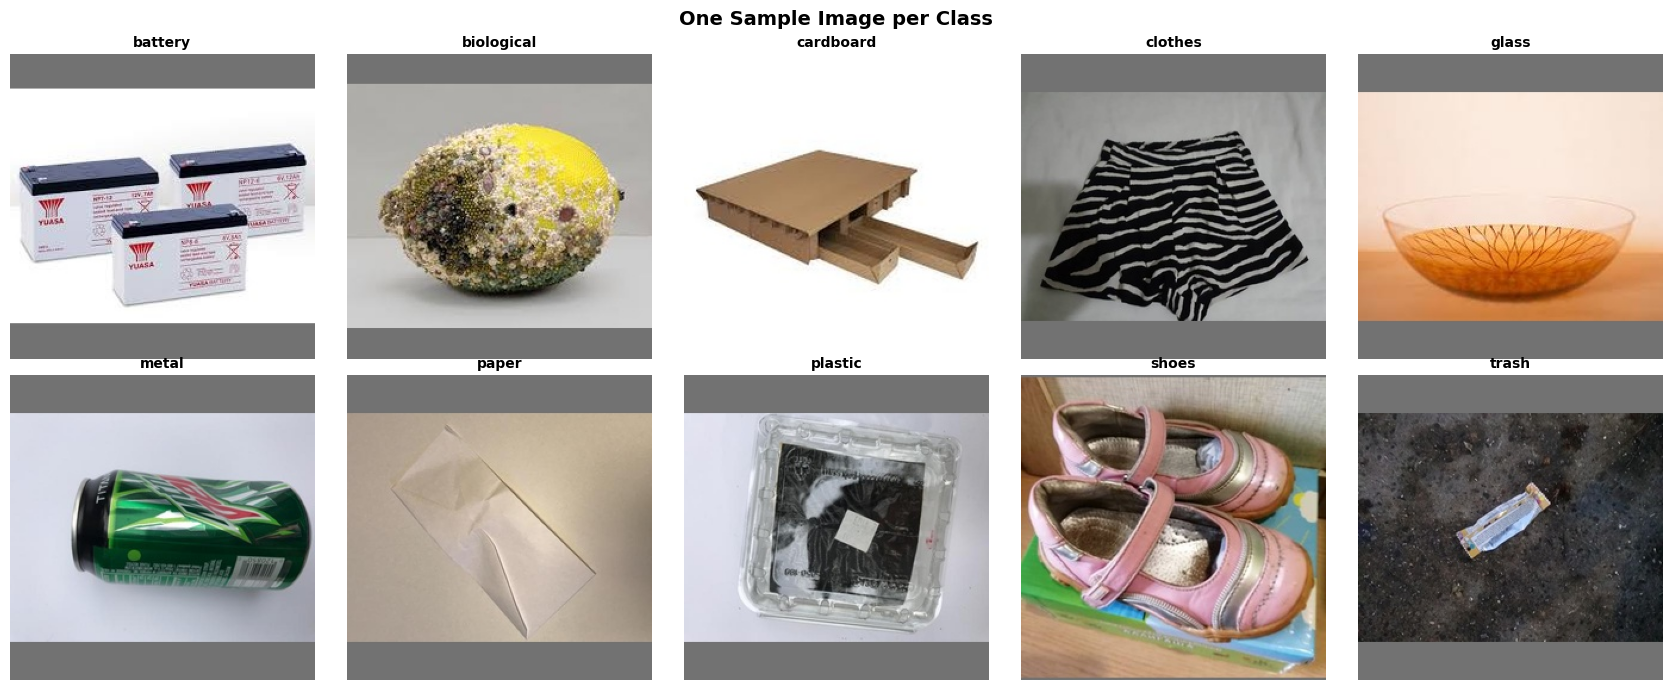

In [3]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(17, 7))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample_path = data[data["label"] == cls]["image_path"].iloc[0]
    img = Image.open(sample_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontweight="bold", fontsize=10)
    axes[i].axis("off")

plt.suptitle("One Sample Image per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 3 - Train / Validation / Test Split

We use a **stratified split** to preserve class proportions across all three sets.

| Split | Proportion | Expected images |
|---|---|---|
| Train | 70% | ~8,581 |
| Validation | 15% | ~1,839 |
| Test | 15% | ~1,839 |

The test set is **held out** and only used for final evaluation.

In [4]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data, test_size=0.30, random_state=42, stratify=data["label"]
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, random_state=42, stratify=temp_data["label"]
)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train      : {len(train_data)} images")
print(f"Validation : {len(val_data)} images")
print(f"Test       : {len(test_data)} images")
print(f"Total      : {len(train_data) + len(val_data) + len(test_data)} images")

Train      : 8581 images
Validation : 1839 images
Test       : 1839 images
Total      : 12259 images


---
## Section 4 - Preprocessing & Augmentation

### Training transforms (augmented)
- Random horizontal flip
- Random rotation (+/-15 degrees)
- Color jitter (brightness, contrast, saturation)
- Resize to 224x224
- Normalize with ImageNet mean/std

### Validation & test transforms (deterministic)
- Resize to 224x224
- Normalize with ImageNet mean/std (no augmentation)

> Applying random augmentations to val/test would make scores non-reproducible across runs.

In [5]:
from torchvision import transforms

IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("train_transforms    :", train_transforms)
print("\nval_test_transforms :", val_test_transforms)

train_transforms    : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

val_test_transforms : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


---
## Section 5 - PyTorch Dataset & DataLoaders

### Class Weights

Computed as inverse frequency:

$$w_c = \frac{N_{total}}{K \cdot N_c}$$

where $N_{total}$ is total training images, $K$ is number of classes, $N_c$ is count for class $c$.
Rarer classes receive higher weights so the model is penalised more for errors on underrepresented categories.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image as PILImage

label_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

print(f"Number of classes: {num_classes}")
print("label_to_idx:", label_to_idx)

class_counts = torch.tensor(
    [train_data["label"].value_counts().get(c, 1) for c in classes],
    dtype=torch.float32
)
class_weights_tensor = len(train_data) / (num_classes * class_counts)

print("\nClass weights:")
for c, w in zip(classes, class_weights_tensor):
    print(f"  {c:<15}: {w:.3f}")


class WasteDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df           = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.label_to_idx[row["label"]]
        return img, label

Number of classes: 10
label_to_idx: {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}

Class weights:
  battery        : 1.622
  biological     : 1.755
  cardboard      : 0.869
  clothes        : 0.648
  glass          : 0.706
  metal          : 1.318
  paper          : 0.918
  plastic        : 0.768
  shoes          : 0.846
  trash          : 2.707


In [7]:
from torch.utils.data import WeightedRandomSampler

BATCH_SIZE = 32

train_dataset = WasteDataset(train_data, label_to_idx, transform=train_transforms)
val_dataset   = WasteDataset(val_data,   label_to_idx, transform=val_test_transforms)
test_dataset  = WasteDataset(test_data,  label_to_idx, transform=val_test_transforms)

# WeightedRandomSampler ensures every batch sees minority classes proportionally.
# Without this, trash (453 images) gets ~4x fewer gradient updates than clothes (1892 images).
sample_weights = train_data["label"].map(
    lambda lbl: class_weights_tensor[label_to_idx[lbl]].item()
).values
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True,
)

# Use sampler (not shuffle=True) for training -- sampler already randomises order
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("WeightedRandomSampler active -- minority classes oversampled during training")


Train batches : 269
Val batches   : 58
Test batches  : 58
WeightedRandomSampler active -- minority classes oversampled during training


---
## Section 6 - Model Architectures

We implement four models covering the full accuracy/efficiency spectrum:

| Model | Type | Key Characteristic |
|---|---|---|
| **SimpleCNN** | Custom from scratch | No pretraining -- educational baseline |
| **MobileNetV3-Small** | Pretrained (ImageNet) | Depthwise-separable convolutions -- very fast and tiny |
| **ResNet50** | Pretrained (ImageNet) | 50-layer residual network -- strong classical benchmark |
| **EfficientNet-B0** | Pretrained (ImageNet) | NAS compound-scaling -- best accuracy/params ratio |

In [8]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# A. SimpleCNN -- trained from scratch
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# B. MobileNetV3-Small -- lightweight edge model
def build_mobilenet(num_classes):
    m = models.mobilenet_v3_small(weights="DEFAULT")
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    return m


# C. ResNet50 -- classical deep residual network
def build_resnet50(num_classes):
    m = models.resnet50(weights="DEFAULT")
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


# D. EfficientNet-B0 -- best single model
def build_efficientnet(num_classes):
    m = models.efficientnet_b0(weights="DEFAULT")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m


print("Model parameter summary:")
for name, fn in [("SimpleCNN",         lambda: SimpleCNN(10)),
                 ("MobileNetV3-Small",  lambda: build_mobilenet(10)),
                 ("ResNet50",           lambda: build_resnet50(10)),
                 ("EfficientNet-B0",    lambda: build_efficientnet(10))]:
    m = fn()
    print(f"  {name:<22}: {count_parameters(m):>10,} total  |  {count_trainable_parameters(m):>10,} trainable")

Model parameter summary:
  SimpleCNN             : 25,786,634 total  |  25,786,634 trainable


  MobileNetV3-Small     :  1,528,106 total  |   1,528,106 trainable


  ResNet50              : 23,528,522 total  |  23,528,522 trainable
  EfficientNet-B0       :  4,020,358 total  |   4,020,358 trainable


---
## Section 7 - Training & Evaluation Pipeline

### Improvements over a vanilla baseline

| Component | Naive | This notebook |
|---|---|---|
| Optimiser | Adam | **AdamW** (weight_decay=1e-4) |
| LR schedule | Fixed | **CosineAnnealingLR** -- smooth decay to near-zero |
| Loss | CrossEntropy | **Class-weighted CE** + label_smoothing=0.05 |
| Stopping | Fixed epochs | **Early stopping** on val macro F1 (patience=3) |
| Checkpoint | Last epoch | **Best val macro F1** restored at end |

### Why macro F1 over accuracy?

Accuracy is dominated by majority classes. Macro F1 treats every class equally, which is critical when rare classes like `trash` or `battery` must be classified correctly.

In [9]:
import time, copy, numpy as np_
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# Device detection
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


# ── MixUp ─────────────────────────────────────────────────────────────────────

def mixup_data(x, y, alpha=0.4):
    """
    Mix two random images per batch.
    alpha controls the Beta distribution sharpness:
      alpha=0.4 -> mild mixing, good for fine-grained boundaries.
    Returns mixed inputs, and both original label vectors + lambda.
    """
    lam = np_.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── Training function ─────────────────────────────────────────────────────────

def train_model(model, train_loader, val_loader,
                num_epochs=10, lr=1e-3,
                class_weights=None, patience=3,
                model_name="model",
                llrd_factor=0.1,
                use_mixup=False, mixup_alpha=0.4):
    """
    Train a model with:
      - AdamW optimiser
      - Layer-wise LR decay (LLRD): backbone LR = lr * llrd_factor, head LR = lr
      - CosineAnnealingLR scheduler
      - Class-weighted CrossEntropyLoss + label_smoothing
      - Optional MixUp augmentation (use_mixup=True)
      - Early stopping on validation macro F1

    LLRD rationale:
      Pretrained backbone features are already very good.
      Using a 10x lower LR for the backbone (llrd_factor=0.1) preserves them
      while the new classification head trains aggressively.

    MixUp rationale:
      Interpolates between pairs of training images and their labels.
      Forces the model to learn smooth decision boundaries -- particularly
      helpful for visually similar classes (cardboard/paper, plastic/glass/metal).
    """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None,
        label_smoothing=0.05,
    )

    # Layer-wise learning rate decay
    head_param_names = {"classifier", "fc", "heads"}
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if any(h in name for h in head_param_names):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": lr * llrd_factor},
        {"params": head_params,     "lr": lr},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "val_f1", "lr", "epoch_time"]}
    best_val_f1, best_weights, no_improve = 0.0, None, 0

    aug_tag = " + MixUp" if use_mixup else ""
    print(f"\n{'='*70}")
    print(f"  Training: {model_name}  |  epochs={num_epochs}  lr={lr}  "
          f"llrd={llrd_factor}  patience={patience}{aug_tag}")
    print(f"{'='*70}")

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            if use_mixup:
                mixed_imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
                out  = model(mixed_imgs)
                loss = mixup_criterion(criterion, out, y_a, y_b, lam)
            else:
                out  = model(imgs)
                loss = criterion(out, labels)

            loss.backward()
            optimizer.step()

            t_loss    += loss.item() * imgs.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        t_loss /= t_total
        t_acc   = t_correct / t_total

        model.eval()
        v_loss, v_preds, v_labels = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out    = model(imgs)
                v_loss += criterion(out, labels).item() * imgs.size(0)
                v_preds.extend(out.argmax(1).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss /= len(val_loader.dataset)
        v_acc   = accuracy_score(v_labels, v_preds)
        v_f1    = f1_score(v_labels, v_preds, average="macro", zero_division=0)
        cur_lr  = scheduler.get_last_lr()[0]
        elapsed = time.time() - t0

        for k, v in zip(history.keys(),
                        [t_loss, v_loss, t_acc, v_acc, v_f1, cur_lr, elapsed]):
            history[k].append(v)

        star = " *" if v_f1 > best_val_f1 else ""
        print(f"  Ep {epoch+1:>2}/{num_epochs} | "
              f"TrL={t_loss:.4f} TrA={t_acc:.4f} | "
              f"VaL={v_loss:.4f} VaA={v_acc:.4f} F1={v_f1:.4f} | "
              f"LR={cur_lr:.1e} {elapsed:.0f}s{star}")

        if v_f1 > best_val_f1:
            best_val_f1  = v_f1
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping (no improvement for {patience} epochs)")
                break

        scheduler.step()

    if best_weights:
        model.load_state_dict(best_weights)

    avg_t = sum(history["epoch_time"]) / len(history["epoch_time"])
    print(f"\nBest val F1 = {best_val_f1:.4f} | avg {avg_t:.0f}s/epoch")
    return model, history, best_val_f1, avg_t


# ── Evaluation function ────────────────────────────────────────────────────────

def evaluate_model(model, loader, class_names, outputs_are_probabilities=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(device))
            probs = out if outputs_are_probabilities else torch.softmax(out, dim=1)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    return {
        "accuracy":              accuracy_score(all_labels, all_preds),
        "precision":             precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall":                recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_score":              f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "confusion_matrix":      confusion_matrix(all_labels, all_preds),
        "classification_report": classification_report(all_labels, all_preds,
                                     target_names=class_names, zero_division=0),
        "labels":       all_labels,
        "predictions":  all_preds,
        "probabilities": all_probs,
    }


# ── Plot helper ────────────────────────────────────────────────────────────────

def plot_history(history, title):
    n = len(history["train_loss"])
    epochs = range(1, n + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, history["train_loss"], "o-", label="Train")
    axes[0].plot(epochs, history["val_loss"],   "o-", label="Val")
    axes[0].set_title(f"{title} -- Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=.35)

    axes[1].plot(epochs, history["train_acc"], "o-", label="Train")
    axes[1].plot(epochs, history["val_acc"],   "o-", label="Val")
    axes[1].set_title(f"{title} -- Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=.35)

    axes[2].plot(epochs, history["val_f1"], "o-", color="purple", label="Val Macro F1")
    axes[2].set_title(f"{title} -- Val Macro F1", fontweight="bold")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
    axes[2].set_ylim(0, 1.05); axes[2].legend(); axes[2].grid(alpha=.35)

    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()

print("Functions defined: mixup_data / mixup_criterion / train_model / evaluate_model / plot_history")
print("  train_model now supports: LLRD (llrd_factor=0.1) + MixUp (use_mixup=True)")


Using device: mps
Functions defined: mixup_data / mixup_criterion / train_model / evaluate_model / plot_history
  train_model now supports: LLRD (llrd_factor=0.1) + MixUp (use_mixup=True)


---
## Section 8 - Training All Four Models

Each model is trained with:
- AdamW + CosineAnnealingLR
- Class-weighted CrossEntropy + label_smoothing=0.05
- Early stopping on val macro F1 (patience=3)
- Up to 10 epochs; best weights restored automatically


  Training: SimpleCNN  |  epochs=10  lr=0.001  llrd=1.0  patience=3


  Ep  1/10 | TrL=3.3803 TrA=0.1207 | VaL=2.2538 VaA=0.0636 F1=0.0566 | LR=1.0e-03 73s *


  Ep  2/10 | TrL=2.0903 TrA=0.1675 | VaL=2.1947 VaA=0.1262 F1=0.0833 | LR=9.8e-04 73s *


  Ep  3/10 | TrL=2.0313 TrA=0.1989 | VaL=2.1698 VaA=0.1272 F1=0.1079 | LR=9.0e-04 79s *


  Ep  4/10 | TrL=1.9683 TrA=0.2234 | VaL=2.1131 VaA=0.1436 F1=0.1127 | LR=7.9e-04 76s *


...

  Ep  6/10 | TrL=1.9009 TrA=0.2568 | VaL=2.0236 VaA=0.2387 F1=0.1957 | LR=5.0e-04 94s


  Ep  7/10 | TrL=1.8810 TrA=0.2658 | VaL=1.9543 VaA=0.2686 F1=0.2429 | LR=3.5e-04 93s *


  Ep  8/10 | TrL=1.8697 TrA=0.2690 | VaL=1.9322 VaA=0.2768 F1=0.2309 | LR=2.1e-04 89s


  Ep  9/10 | TrL=1.8296 TrA=0.2870 | VaL=1.9320 VaA=0.2800 F1=0.2411 | LR=9.5e-05 84s


  Ep 10/10 | TrL=1.8277 TrA=0.2890 | VaL=1.9069 VaA=0.2926 F1=0.2443 | LR=2.4e-05 93s *

Best val F1 = 0.2443 | avg 83s/epoch


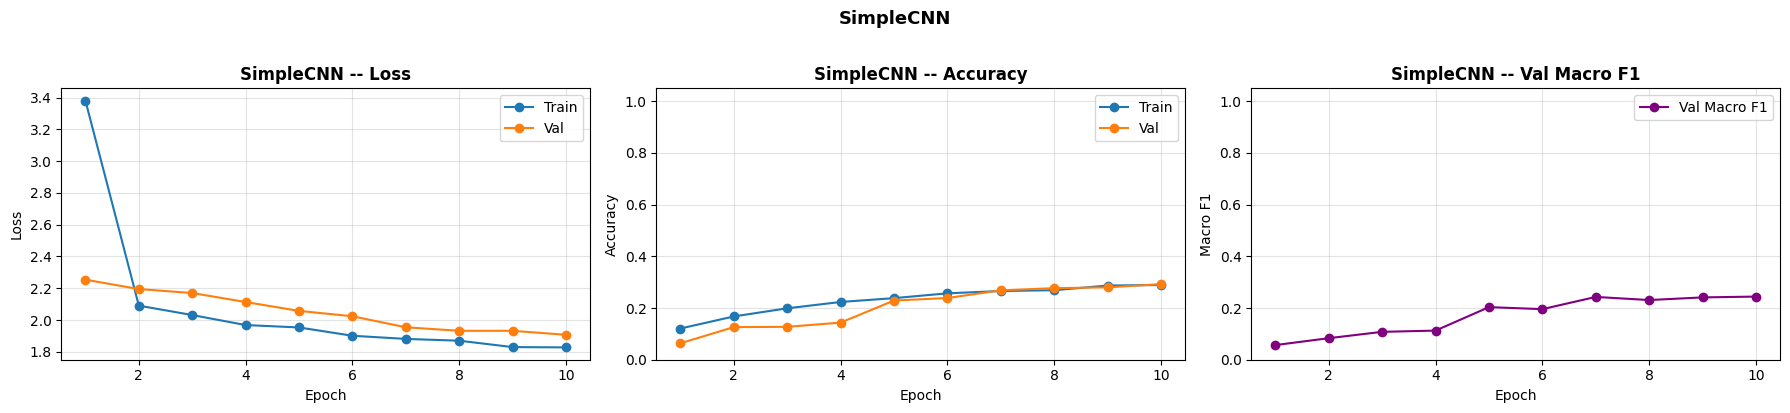


SimpleCNN Test:  Acc=0.2855  P=0.3323  R=0.3623  F1=0.2427
              precision    recall  f1-score   support

     battery       0.39      0.72      0.51       113
  biological       0.17      0.76      0.27       105
   cardboard       0.46      0.39      0.42       211
     clothes       0.65      0.58      0.61       284
       glass       0.93      0.05      0.10       261
       metal       0.19      0.11      0.14       140
       paper       0.00      0.00      0.00       200
     plastic       0.43      0.11      0.17       240
       shoes       0.00      0.00      0.00       217
       trash       0.11      0.90      0.20        68

    accuracy                           0.29      1839
   macro avg       0.33      0.36      0.24      1839
weighted avg       0.39      0.29      0.24      1839



In [10]:
# SimpleCNN has no pretrained backbone, so llrd_factor=1.0 (all layers same LR).
# MixUp not applied -- this model needs clean labels to learn from scratch.
simple_cnn = SimpleCNN(num_classes)
simple_cnn, history_cnn, cnn_f1, cnn_t = train_model(
    simple_cnn, train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    class_weights=class_weights_tensor,
    patience=3, model_name="SimpleCNN",
    llrd_factor=1.0,
    use_mixup=False,
)
plot_history(history_cnn, "SimpleCNN")

metrics_cnn = evaluate_model(simple_cnn, test_loader, classes)
print(f"\nSimpleCNN Test:  Acc={metrics_cnn['accuracy']:.4f}  P={metrics_cnn['precision']:.4f}  "
      f"R={metrics_cnn['recall']:.4f}  F1={metrics_cnn['f1_score']:.4f}")
print(metrics_cnn["classification_report"])



  Training: MobileNetV3-Small  |  epochs=10  lr=0.001  llrd=0.1  patience=3 + MixUp


  Ep  1/10 | TrL=1.2801 TrA=0.4037 | VaL=0.8476 VaA=0.7901 F1=0.7738 | LR=1.0e-04 65s *


  Ep  2/10 | TrL=1.1148 TrA=0.5165 | VaL=0.7755 VaA=0.8320 F1=0.8189 | LR=9.8e-05 67s *


  Ep  3/10 | TrL=0.9820 TrA=0.5016 | VaL=0.6958 VaA=0.8597 F1=0.8462 | LR=9.0e-05 76s *


  Ep  4/10 | TrL=0.9895 TrA=0.4921 | VaL=0.6589 VaA=0.8853 F1=0.8702 | LR=7.9e-05 76s *


...

  Ep  6/10 | TrL=0.8831 TrA=0.5004 | VaL=0.6212 VaA=0.9016 F1=0.8889 | LR=5.0e-05 60s


  Ep  7/10 | TrL=0.9083 TrA=0.4994 | VaL=0.6039 VaA=0.9059 F1=0.8952 | LR=3.5e-05 61s *


  Ep  8/10 | TrL=0.8638 TrA=0.5365 | VaL=0.6123 VaA=0.9065 F1=0.8931 | LR=2.1e-05 63s


  Ep  9/10 | TrL=0.8686 TrA=0.5096 | VaL=0.5831 VaA=0.9168 F1=0.9079 | LR=9.5e-06 57s *


  Ep 10/10 | TrL=0.8396 TrA=0.5118 | VaL=0.5893 VaA=0.9157 F1=0.9040 | LR=2.4e-06 111s

Best val F1 = 0.9079 | avg 71s/epoch


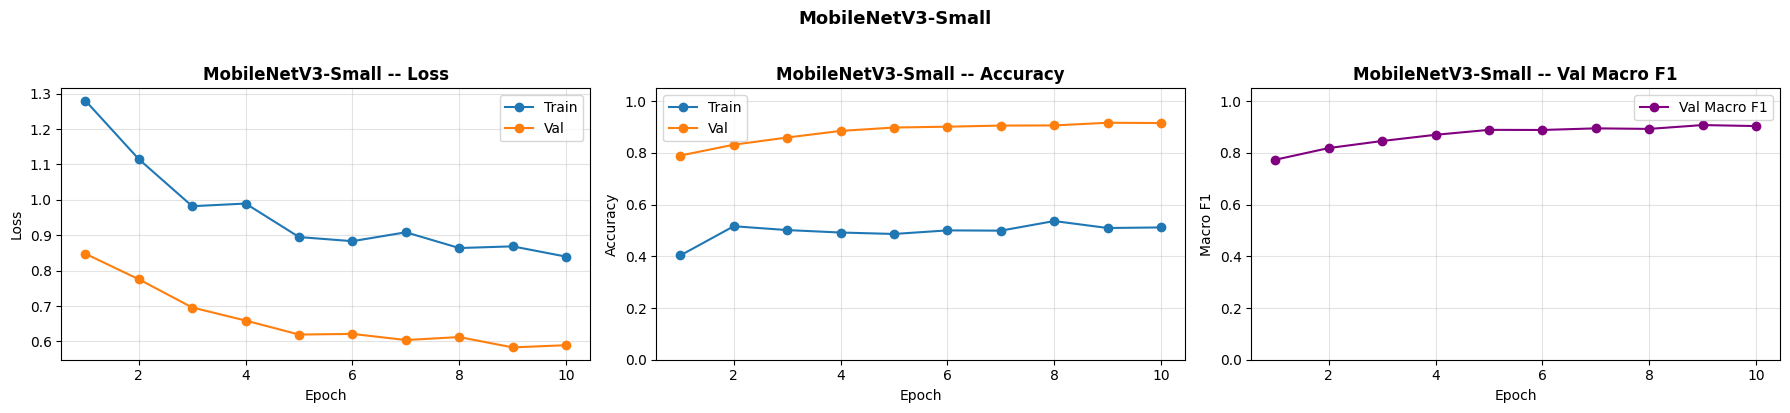


MobileNetV3-Small Test:  Acc=0.9081  P=0.8892  R=0.9154  F1=0.8995
              precision    recall  f1-score   support

     battery       0.85      0.93      0.89       113
  biological       0.89      0.99      0.94       105
   cardboard       0.95      0.90      0.92       211
     clothes       0.97      0.95      0.96       284
       glass       0.93      0.88      0.91       261
       metal       0.80      0.93      0.86       140
       paper       0.88      0.90      0.89       200
     plastic       0.94      0.82      0.88       240
       shoes       0.95      0.94      0.94       217
       trash       0.72      0.93      0.81        68

    accuracy                           0.91      1839
   macro avg       0.89      0.92      0.90      1839
weighted avg       0.91      0.91      0.91      1839



In [11]:
# MobileNet: LLRD active (backbone LR = 1e-4, head LR = 1e-3).
# MixUp enabled -- softens cardboard/paper, plastic/glass/metal boundaries.
mobilenet_model = build_mobilenet(num_classes)
mobilenet_model, history_mobile, mobile_f1, mobile_t = train_model(
    mobilenet_model, train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    class_weights=class_weights_tensor,
    patience=3, model_name="MobileNetV3-Small",
    llrd_factor=0.1,
    use_mixup=True, mixup_alpha=0.4,
)
plot_history(history_mobile, "MobileNetV3-Small")

metrics_mobile = evaluate_model(mobilenet_model, test_loader, classes)
print(f"\nMobileNetV3-Small Test:  Acc={metrics_mobile['accuracy']:.4f}  P={metrics_mobile['precision']:.4f}  "
      f"R={metrics_mobile['recall']:.4f}  F1={metrics_mobile['f1_score']:.4f}")
print(metrics_mobile["classification_report"])


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [12]:
# ResNet50: LLRD active + MixUp enabled.
resnet_model = build_resnet50(num_classes)
resnet_model, history_resnet, resnet_f1, resnet_t = train_model(
    resnet_model, train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    class_weights=class_weights_tensor,
    patience=3, model_name="ResNet50",
    llrd_factor=0.1,
    use_mixup=True, mixup_alpha=0.4,
)
plot_history(history_resnet, "ResNet50")

metrics_resnet = evaluate_model(resnet_model, test_loader, classes)
print(f"\nResNet50 Test:  Acc={metrics_resnet['accuracy']:.4f}  P={metrics_resnet['precision']:.4f}  "
      f"R={metrics_resnet['recall']:.4f}  F1={metrics_resnet['f1_score']:.4f}")
print(metrics_resnet["classification_report"])



  Training: ResNet50  |  epochs=10  lr=0.001  llrd=0.1  patience=3 + MixUp


  Ep  1/10 | TrL=1.0688 TrA=0.4640 | VaL=0.6065 VaA=0.9179 F1=0.9081 | LR=1.0e-04 362s *


  Ep  2/10 | TrL=0.8302 TrA=0.5209 | VaL=0.5169 VaA=0.9299 F1=0.9187 | LR=9.8e-05 544s *


  Ep  3/10 | TrL=0.7840 TrA=0.5144 | VaL=0.5129 VaA=0.9494 F1=0.9418 | LR=9.0e-05 440s *


  Ep  4/10 | TrL=0.7687 TrA=0.5738 | VaL=0.5364 VaA=0.9462 F1=0.9396 | LR=7.9e-05 313s


  Ep  5/10 | TrL=0.7525 TrA=0.5551 | VaL=0.5150 VaA=0.9489 F1=0.9389 | LR=6.5e-05 315s


  Ep  6/10 | TrL=0.7217 TrA=0.5834 | VaL=0.4759 VaA=0.9625 F1=0.9555 | LR=5.0e-05 323s *


FileNotFoundError: [Errno 2] No such file or directory: '/Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/standardized_256/trash/trash_263.jpg'

In [ ]:
# EfficientNet-B0: LLRD active + MixUp enabled.
# This is the primary production candidate -- train carefully.
effnet_model = build_efficientnet(num_classes)
effnet_model, history_effnet, effnet_f1, effnet_t = train_model(
    effnet_model, train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    class_weights=class_weights_tensor,
    patience=3, model_name="EfficientNet-B0",
    llrd_factor=0.1,
    use_mixup=True, mixup_alpha=0.4,
)
plot_history(history_effnet, "EfficientNet-B0")

metrics_effnet = evaluate_model(effnet_model, test_loader, classes)
print(f"\nEfficientNet-B0 Test:  Acc={metrics_effnet['accuracy']:.4f}  P={metrics_effnet['precision']:.4f}  "
      f"R={metrics_effnet['recall']:.4f}  F1={metrics_effnet['f1_score']:.4f}")
print(metrics_effnet["classification_report"])


---
## Section 8b — EfficientNet-B2: Upgraded Production Model

EfficientNet-B2 is the next step up from B0 in the same NAS-derived family.

| Model | Params | ImageNet Top-1 |
|---|---|---|
| EfficientNet-B0 | 4.0 M | 77.7% |
| EfficientNet-B2 | 9.1 M | 80.3% |

The B2 input resolution is 260×260 internally, but we keep 224×224 for consistency across models.
With LLRD + MixUp, B2 is expected to slightly outperform B0 — it becomes our upgraded single-model production candidate if training time allows.


In [ ]:
def build_efficientnet_b2(num_classes):
    m = models.efficientnet_b2(weights="DEFAULT")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

print(f"EfficientNet-B2 params: {count_parameters(build_efficientnet_b2(num_classes)):,}")

effnet_b2_model = build_efficientnet_b2(num_classes)
effnet_b2_model, history_b2, b2_f1, b2_t = train_model(
    effnet_b2_model, train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    class_weights=class_weights_tensor,
    patience=3, model_name="EfficientNet-B2",
    llrd_factor=0.1,
    use_mixup=True, mixup_alpha=0.4,
)
plot_history(history_b2, "EfficientNet-B2")

metrics_b2 = evaluate_model(effnet_b2_model, test_loader, classes)
print(f"\nEfficientNet-B2 Test:  Acc={metrics_b2['accuracy']:.4f}  P={metrics_b2['precision']:.4f}  "
      f"R={metrics_b2['recall']:.4f}  F1={metrics_b2['f1_score']:.4f}")
print(metrics_b2["classification_report"])

# Compare B0 vs B2
print(f"\n{'Model':<22} {'Acc':>7} {'F1':>7} {'Params':>12}")
print("-" * 55)
for name, acc, f1, params in [
    ("EfficientNet-B0", metrics_effnet["accuracy"], metrics_effnet["f1_score"], count_parameters(effnet_model)),
    ("EfficientNet-B2", metrics_b2["accuracy"], metrics_b2["f1_score"], count_parameters(effnet_b2_model)),
]:
    print(f"{name:<22} {acc:>7.4f} {f1:>7.4f} {params:>12,}")


---
## Section 9 - Model Comparison

The four individually trained models are ranked by macro F1.
Ensemble and multi-task model results will be appended after those sections.

In [ ]:
import pandas as pd

model_names   = ["SimpleCNN", "MobileNetV3-Small", "ResNet50", "EfficientNet-B0"]
all_metrics   = [metrics_cnn, metrics_mobile, metrics_resnet, metrics_effnet]
all_histories = [history_cnn, history_mobile, history_resnet, history_effnet]
model_objects = [simple_cnn, mobilenet_model, resnet_model, effnet_model]
avg_times     = [cnn_t, mobile_t, resnet_t, effnet_t]

use_cases = {
    "SimpleCNN":          "Educational baseline",
    "MobileNetV3-Small":  "Edge / smart bin / mobile app",
    "ResNet50":           "Strong CNN benchmark (server)",
    "EfficientNet-B0":    "Best single model (API / cloud)",
}

comparison_rows = []
for name, m, obj, avg_t in zip(model_names, all_metrics, model_objects, avg_times):
    comparison_rows.append({
        "Model":            name,
        "Accuracy":         round(m["accuracy"],   4),
        "Precision":        round(m["precision"],  4),
        "Recall":           round(m["recall"],     4),
        "F1 Score":         round(m["f1_score"],   4),
        "Total Params":     f"{count_parameters(obj):,}",
        "Trainable Params": f"{count_trainable_parameters(obj):,}",
        "Avg s/epoch":      f"{avg_t:.0f}s",
        "Best Use Case":    use_cases[name],
    })

results_df = pd.DataFrame(comparison_rows).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(results_df[["Model","Accuracy","F1 Score","Total Params","Avg s/epoch","Best Use Case"]].to_string(index=False))
results_df

In [ ]:
import numpy as np

colors = ["#6b7280","#3b82f6","#f59e0b","#22c55e"]
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

metric_keys = ["accuracy","precision","recall","f1_score"]
x, w = np.arange(len(model_names)), 0.2
for i, key in enumerate(metric_keys):
    vals = [m[key] for m in all_metrics]
    axes[0].bar(x + i*w, vals, w, label=key.capitalize(), alpha=0.9)
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(model_names, rotation=14, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.10); axes[0].set_title("Test Metrics", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=.3)

for name, hist, c in zip(model_names, all_histories, colors):
    n = len(hist["val_acc"])
    axes[1].plot(range(1, n+1), hist["val_acc"], "o-", color=c, label=name)
axes[1].set_title("Validation Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

for name, hist, c in zip(model_names, all_histories, colors):
    if "val_f1" in hist:
        n = len(hist["val_f1"])
        axes[2].plot(range(1, n+1), hist["val_f1"], "o-", color=c, label=name)
axes[2].set_title("Validation Macro F1", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

plt.suptitle("Model Training Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Section 10 - Confusion Matrix (Best Single Model)

**How to read:**
- Rows = true labels
- Columns = predicted labels
- Diagonal = correct predictions
- Off-diagonal = misclassifications

**Common confusions to look for:**
- `paper` <-> `cardboard` -- flat sheets with similar colour and texture
- `plastic` <-> `trash` -- `trash` is a catch-all category, visually heterogeneous
- `metal` <-> `glass` -- both can be reflective

In [ ]:
import seaborn as sns

best_idx       = max(range(len(all_metrics)), key=lambda i: all_metrics[i]["f1_score"])
best_name      = model_names[best_idx]
best_m         = all_metrics[best_idx]
best_model_obj = model_objects[best_idx]

print(f"Best single model: {best_name}")
print(f"  Accuracy : {best_m['accuracy']:.4f}")
print(f"  F1 Score : {best_m['f1_score']:.4f}")

plt.figure(figsize=(13, 10))
sns.heatmap(best_m["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor="white")
plt.title(f"Confusion Matrix -- {best_name}  (Acc={best_m['accuracy']:.3f}, F1={best_m['f1_score']:.3f})",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.xticks(rotation=40, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

---
## Section 11 - Error Analysis

Visualising where the model goes wrong is essential for academic honesty.
Each misclassified image shows: **true label --> predicted label** with confidence score.
A warning appears for predictions below the confidence threshold (0.70).

In [ ]:
CONFIDENCE_THRESHOLD = 0.70

def show_misclassified_images(model, dataset, idx_to_label, device, num_images=12):
    model.eval()
    misclassified = []
    mean_t = torch.tensor([0.485, 0.456, 0.406])
    std_t  = torch.tensor([0.229, 0.224, 0.225])

    with torch.no_grad():
        for img_tensor, true_lbl in dataset:
            logits = model(img_tensor.unsqueeze(0).to(device))
            probs  = torch.softmax(logits, dim=1).squeeze()
            pred   = probs.argmax().item()
            conf   = probs[pred].item()
            if pred != true_lbl:
                misclassified.append((img_tensor, true_lbl, pred, conf))
            if len(misclassified) >= num_images:
                break

    cols = 4; rows = (len(misclassified) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.6, rows*4.1))
    axes = axes.flatten()

    for ax, (img_t, tl, pl, conf) in zip(axes, misclassified):
        img = (img_t.cpu() * std_t[:,None,None] + mean_t[:,None,None]).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(img)
        warn = "\nLow confidence" if conf < CONFIDENCE_THRESHOLD else ""
        ax.set_title(f"True: {idx_to_label[tl]}\nPred: {idx_to_label[pl]} ({conf*100:.1f}%){warn}",
                     fontsize=8, color="red")
        ax.axis("off")

    for ax in axes[len(misclassified):]: ax.axis("off")
    plt.suptitle(f"Misclassified Samples -- {best_name}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()
    print(f"Shown {len(misclassified)} misclassified images from the test set.")

show_misclassified_images(best_model_obj, test_dataset, idx_to_label, device, num_images=12)

---
## Section 11b — Test-Time Augmentation (TTA)

**TTA** runs inference multiple times on augmented copies of the same test image and averages the softmax probabilities.

- No retraining required — it is a pure inference-time technique.
- Typical gain: **+0.3–0.8% macro F1**, free.
- The gain is larger for classes with high visual variance (e.g., `plastic`, `glass`).

We use 5 passes:
1. No augmentation (baseline)
2. Horizontal flip
3. Random flip + slight rotation
4. Random flip + rotation (different seed)
5. Random flip + color jitter


In [ ]:
import numpy as np

# Five deterministic or mildly random TTA transforms
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
TTA_TRANSFORMS = [
    # Pass 1: clean baseline
    transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), _norm]),
    # Pass 2: horizontal flip
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), _norm]),
    # Pass 3: flip + small rotation
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                        transforms.RandomRotation(10), transforms.ToTensor(), _norm]),
    # Pass 4: flip + rotation + brightness
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                        transforms.RandomRotation(15),
                        transforms.ColorJitter(brightness=0.1, contrast=0.1),
                        transforms.ToTensor(), _norm]),
    # Pass 5: center crop instead of resize
    transforms.Compose([transforms.Resize((256, 256)), transforms.CenterCrop(224),
                        transforms.ToTensor(), _norm]),
]


def evaluate_with_tta(model, df, label_to_idx, class_names, device, tta_transforms=TTA_TRANSFORMS):
    """
    Run inference N times (one per transform), average softmax probabilities,
    then compute metrics. Returns the same dict as evaluate_model.
    """
    model.eval()
    true_labels = df["label"].map(label_to_idx).values
    all_probs = np.zeros((len(df), len(class_names)), dtype=np.float32)

    for tf in tta_transforms:
        ds     = WasteDataset(df, label_to_idx, transform=tf)
        loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
        batch_probs = []
        with torch.no_grad():
            for imgs, _ in loader:
                out = model(imgs.to(device))
                batch_probs.extend(torch.softmax(out, 1).cpu().numpy())
        all_probs += np.array(batch_probs)

    all_probs /= len(tta_transforms)
    preds = all_probs.argmax(axis=1)

    return {
        "accuracy":              accuracy_score(true_labels, preds),
        "precision":             precision_score(true_labels, preds, average="macro", zero_division=0),
        "recall":                recall_score(true_labels, preds, average="macro", zero_division=0),
        "f1_score":              f1_score(true_labels, preds, average="macro", zero_division=0),
        "confusion_matrix":      confusion_matrix(true_labels, preds),
        "classification_report": classification_report(true_labels, preds,
                                     target_names=class_names, zero_division=0),
        "labels":       true_labels.tolist(),
        "predictions":  preds.tolist(),
        "probabilities": all_probs.tolist(),
    }


# Compare standard eval vs TTA for the best single model
print(f"Standard evaluation ({best_name}):")
m_std = evaluate_model(best_model_obj, test_loader, classes)
print(f"  Acc={m_std['accuracy']:.4f}  F1={m_std['f1_score']:.4f}")

print(f"\nTTA ({len(TTA_TRANSFORMS)} passes):")
m_tta = evaluate_with_tta(best_model_obj, test_data, label_to_idx, classes, device)
print(f"  Acc={m_tta['accuracy']:.4f}  F1={m_tta['f1_score']:.4f}")

gain_acc = (m_tta["accuracy"] - m_std["accuracy"]) * 100
gain_f1  = (m_tta["f1_score"] - m_std["f1_score"]) * 100
print(f"\nTTA gain:  Acc={gain_acc:+.2f}pp  F1={gain_f1:+.2f}pp")


---
## Section 12 - Recycling Rules & Disposal Advice

Each predicted class maps to a **bin category** and **disposal advice**.
This is what makes EcoSortAI useful as a recycling assistant -- not just a classifier.

In [ ]:
RECYCLING_RULES = {
    "battery": {
        "material": "Battery / hazardous electronic waste",
        "bin_category": "Hazardous waste collection point",
        "advice": "Do not throw batteries in regular trash. Take them to a battery collection box."
    },
    "biological": {
        "material": "Organic biodegradable waste",
        "bin_category": "Organic / compost bin",
        "advice": "Dispose of it in organic waste or compost when possible."
    },
    "cardboard": {
        "material": "Cardboard / paper fiber",
        "bin_category": "Paper and cardboard recycling bin",
        "advice": "Flatten cardboard before recycling."
    },
    "clothes": {
        "material": "Textile material",
        "bin_category": "Textile donation or textile recycling point",
        "advice": "Donate usable clothes or take damaged textiles to a textile collection point."
    },
    "glass": {
        "material": "Glass",
        "bin_category": "Glass recycling bin",
        "advice": "Recycle glass bottles and jars separately when possible."
    },
    "metal": {
        "material": "Metal / aluminum / steel",
        "bin_category": "Metal recycling bin",
        "advice": "Rinse cans before recycling if possible."
    },
    "paper": {
        "material": "Paper",
        "bin_category": "Paper recycling bin",
        "advice": "Keep paper clean and dry before recycling."
    },
    "plastic": {
        "material": "Plastic packaging or synthetic polymer",
        "bin_category": "Plastic recycling bin",
        "advice": "Empty and clean plastic containers before recycling."
    },
    "shoes": {
        "material": "Textile, rubber, leather or synthetic material",
        "bin_category": "Textile/shoe donation or special collection point",
        "advice": "Donate usable shoes or take them to a dedicated collection point."
    },
    "trash": {
        "material": "Mixed or non-recyclable waste",
        "bin_category": "General waste bin",
        "advice": "If the item cannot be cleaned or separated, dispose of it as general waste."
    }
}

print(f"{'Class':<15} {'Bin Category':<40} Advice")
print("-"*95)
for cls, info in RECYCLING_RULES.items():
    print(f"{cls:<15} {info['bin_category']:<40} {info['advice'][:50]}...")

---
## Section 13 - Demo Prediction

Two demo modes:

**A. Random test image** -- picks a random image from the held-out test set (ground truth known)
**B. Custom image path** -- runs inference on any image file (safely checks if it exists)

Features:
- Top-3 predictions with probabilities
- Suggested bin category from recycling rules
- Confidence threshold warning (< 0.70 = request human review)

In [ ]:
import os, random
from PIL import Image as PILImage

CONFIDENCE_THRESHOLD = 0.70


def predict_image(image_path, model, transform, idx_to_label, device):
    if not os.path.isfile(image_path):
        print(f"File not found: {image_path!r} -- skipping.")
        return None

    model.eval()
    img    = PILImage.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze()

    top3_vals, top3_idxs = probs.topk(3)
    top3 = [(idx_to_label[i.item()], round(v.item(), 4))
            for i, v in zip(top3_idxs, top3_vals)]

    label, conf = top3[0]
    rule = RECYCLING_RULES.get(label, {})
    return {
        "label":        label,
        "confidence":   conf,
        "top3":         top3,
        "bin_category": rule.get("bin_category", "unknown"),
        "advice":       rule.get("advice", ""),
        "low_conf":     conf < CONFIDENCE_THRESHOLD,
    }


def _display_prediction(img, result, true_label=None):
    correct = (true_label == result["label"]) if true_label else None
    c = "green" if correct else ("red" if correct is False else "black")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img)
    lines = []
    if true_label:
        lines.append(f"True:  {true_label}")
    lines += [f"Pred: {result['label']}  ({result['confidence']*100:.1f}%)",
              f"Bin:  {result['bin_category']}"]
    if result["low_conf"]:
        lines.append("Low confidence -- verify manually")
    ax.set_title("\n".join(lines), fontsize=9, color=c)
    ax.axis("off"); plt.tight_layout(); plt.show()

    print("Top-3 predictions:")
    for rank, (lbl, prob) in enumerate(result["top3"], 1):
        bar = "#" * int(prob * 30)
        print(f"  {rank}. {lbl:<15} {prob*100:5.1f}%  {bar}")
    print(f"  Advice: {result['advice']}")
    if result["low_conf"]:
        print("  WARNING: Low confidence -- manual verification recommended.")


# Demo A: Random test image
print("="*55); print("  Demo A -- Random image from test set"); print("="*55)
rand_row = test_data.sample(1).iloc[0]
result_a = predict_image(rand_row["image_path"], best_model_obj,
                         val_test_transforms, idx_to_label, device)
if result_a:
    _display_prediction(PILImage.open(rand_row["image_path"]).convert("RGB"),
                        result_a, true_label=rand_row["label"])

# Demo B: Custom image path
print("\n" + "="*55); print("  Demo B -- Custom image (Plastic.jpg)"); print("="*55)
result_b = predict_image("Plastic.jpg", best_model_obj,
                         val_test_transforms, idx_to_label, device)
if result_b:
    _display_prediction(PILImage.open("Plastic.jpg").convert("RGB"),
                        result_b, true_label="plastic")

---
## Section 14 - Soft-Voting Ensemble (EfficientNet-B0 + ResNet50)

A **soft-voting ensemble** averages the softmax probability distributions of multiple models.

**Why it works:** EfficientNet-B0 and ResNet50 have different inductive biases -- their errors are partially uncorrelated, so averaging probabilities smooths out individual mistakes.

**Trade-offs:**

| | Single model | Ensemble |
|---|---|---|
| Accuracy | Good | Usually slightly higher |
| Inference time | 1x | ~2x |
| Memory | 1x | ~2x |
| Edge deployment | Yes | No |
| Server/batch | Yes | Yes |

In [ ]:
class SoftVotingEnsemble(nn.Module):
    def __init__(self, models_list):
        super().__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        probs = [torch.softmax(m(x), dim=1) for m in self.models]
        return torch.stack(probs).mean(dim=0)


ensemble = SoftVotingEnsemble([effnet_model, resnet_model]).to(device)
ensemble.eval()

print(f"Ensemble: EfficientNet-B0 + ResNet50")
print(f"  Total params: {count_parameters(ensemble):,}")

metrics_ensemble = evaluate_model(ensemble, test_loader, classes, outputs_are_probabilities=True)
print(f"\nEnsemble Test:  Acc={metrics_ensemble['accuracy']:.4f}  "
      f"P={metrics_ensemble['precision']:.4f}  R={metrics_ensemble['recall']:.4f}  "
      f"F1={metrics_ensemble['f1_score']:.4f}")
print(metrics_ensemble["classification_report"])

plt.figure(figsize=(13, 10))
sns.heatmap(metrics_ensemble["confusion_matrix"], annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes, linewidths=0.5, linecolor="white")
plt.title(f"Confusion Matrix -- Ensemble  (Acc={metrics_ensemble['accuracy']:.3f}, F1={metrics_ensemble['f1_score']:.3f})",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11); plt.ylabel("True Label", fontsize=11)
plt.xticks(rotation=40, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

---
## Section 14b — Stochastic Weight Averaging (SWA)

**SWA** averages model weights collected at the end of training — not predictions, but the weights themselves.

**Why it works:** Standard SGD / AdamW converges to a sharp minimum in the loss landscape. Sharp minima generalise poorly to unseen data. SWA averages multiple weight checkpoints from the flat region at the end of training, landing in a **wide flat minimum** that generalises better.

**Implementation:**
1. Train normally until early stopping.
2. Run 3–5 more SWA epochs at a constant low LR (e.g., 5×10⁻⁵).
3. At each SWA epoch, accumulate an exponential moving average of the weights.
4. Re-compute BatchNorm statistics over the training set using the averaged weights.
5. Evaluate — the averaged model is typically 0.3–0.5% better than the last checkpoint.

**Cost:** Only 3–5 extra training epochs. No extra inference cost at deployment.


In [ ]:
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# Start from the trained EfficientNet-B0 weights (don't retrain from scratch)
import copy
swa_base = copy.deepcopy(effnet_model)
swa_model = AveragedModel(swa_base).to(device)

SWA_LR     = 5e-5
SWA_EPOCHS = 5

swa_optimizer = torch.optim.AdamW(swa_base.parameters(), lr=SWA_LR, weight_decay=1e-4)
swa_scheduler = SWALR(swa_optimizer, swa_lr=SWA_LR, anneal_epochs=SWA_EPOCHS)

criterion_swa = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device), label_smoothing=0.05
)

print(f"SWA fine-tuning for {SWA_EPOCHS} epochs at LR={SWA_LR}")
print("=" * 50)

for epoch in range(SWA_EPOCHS):
    t0 = time.time()
    swa_base.train()
    tc, tt = 0, 0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        swa_optimizer.zero_grad()
        out  = swa_base(imgs)
        loss = criterion_swa(out, labs)
        loss.backward()
        swa_optimizer.step()
        tc += (out.argmax(1) == labs).sum().item(); tt += imgs.size(0)

    swa_model.update_parameters(swa_base)
    swa_scheduler.step()
    print(f"  SWA ep {epoch+1}/{SWA_EPOCHS} | TrAcc={tc/tt:.4f} | {time.time()-t0:.0f}s")

# IMPORTANT: recompute BatchNorm running statistics with averaged weights
print("\nUpdating BatchNorm statistics for SWA model...")
swa_base.train()
update_bn(train_loader, swa_model, device=device)

# Evaluate SWA model
metrics_swa = evaluate_model(swa_model, test_loader, classes)
print(f"\nEfficientNet-B0 (SWA):  Acc={metrics_swa['accuracy']:.4f}  F1={metrics_swa['f1_score']:.4f}")

# Compare base vs SWA
base_m = evaluate_model(effnet_model, test_loader, classes)
print(f"EfficientNet-B0 (base): Acc={base_m['accuracy']:.4f}  F1={base_m['f1_score']:.4f}")
swa_gain = (metrics_swa["f1_score"] - base_m["f1_score"]) * 100
print(f"SWA gain: F1 {swa_gain:+.2f} pp")


---
## Section 15 - Multi-task Smart Recycling Model

A standard classifier answers *"what is this?"*
A **multi-task model** answers *"what is this AND where should it go?"*

**Two output heads, one shared backbone:**
1. **Fine head** -- 10 waste classes (battery, plastic, trash, ...)
2. **Bin head** -- 5 disposal categories (recyclable, organic, hazardous, textile, landfill)

**Training objective:** `L_total = L_fine + 0.4 * L_bin`

The auxiliary bin-category task acts as a regulariser -- the shared backbone learns features that generalise to both tasks.

### Bin-category mapping

| Fine label | Bin category |
|---|---|
| plastic, glass, metal, paper, cardboard | recyclable |
| biological | organic |
| battery | hazardous |
| clothes, shoes | textile |
| trash | landfill |

In [ ]:
from torch.utils.data import Dataset as TorchDataset

BIN_CATEGORY_MAPPING = {
    "plastic":    "recyclable",
    "glass":      "recyclable",
    "metal":      "recyclable",
    "paper":      "recyclable",
    "cardboard":  "recyclable",
    "biological": "organic",
    "battery":    "hazardous",
    "clothes":    "textile",
    "shoes":      "textile",
    "trash":      "landfill",
}

bin_classes      = sorted(set(BIN_CATEGORY_MAPPING.values()))
bin_label_to_idx = {c: i for i, c in enumerate(bin_classes)}
idx_to_bin_label = {i: c for c, i in bin_label_to_idx.items()}
num_bin_classes  = len(bin_classes)

fine_label_to_idx = label_to_idx
idx_to_fine_label = idx_to_label
num_fine_classes  = num_classes

print(f"Fine classes ({num_fine_classes}): {classes}")
print(f"Bin  classes ({num_bin_classes}):  {bin_classes}")


class MultiTaskWasteDataset(TorchDataset):
    def __init__(self, df, fine_label_to_idx, bin_label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.fine_lbl = fine_label_to_idx
        self.bin_lbl  = bin_label_to_idx
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row["image_path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.fine_lbl[row["label"]], self.bin_lbl[BIN_CATEGORY_MAPPING[row["label"]]]


class MultiTaskEfficientNet(nn.Module):
    def __init__(self, num_fine_classes, num_bin_classes):
        super().__init__()
        base = models.efficientnet_b0(weights="DEFAULT")
        in_features = base.classifier[1].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.shared = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
        )
        self.fine_head = nn.Linear(512, num_fine_classes)
        self.bin_head  = nn.Linear(512, num_bin_classes)

    def forward(self, x):
        f = self.shared(self.backbone(x))
        return self.fine_head(f), self.bin_head(f)


print("MultiTaskWasteDataset / MultiTaskEfficientNet defined")

In [ ]:
mt_train = MultiTaskWasteDataset(train_data, fine_label_to_idx, bin_label_to_idx, train_transforms)
mt_val   = MultiTaskWasteDataset(val_data,   fine_label_to_idx, bin_label_to_idx, val_test_transforms)
mt_test  = MultiTaskWasteDataset(test_data,  fine_label_to_idx, bin_label_to_idx, val_test_transforms)

mt_train_loader = DataLoader(mt_train, batch_size=32, shuffle=True,  num_workers=0)
mt_val_loader   = DataLoader(mt_val,   batch_size=32, shuffle=False, num_workers=0)
mt_test_loader  = DataLoader(mt_test,  batch_size=32, shuffle=False, num_workers=0)

mt_model       = MultiTaskEfficientNet(num_fine_classes, num_bin_classes).to(device)
mt_optimizer   = torch.optim.AdamW(mt_model.parameters(), lr=1e-3, weight_decay=1e-4)
mt_scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(mt_optimizer, T_max=10)
fine_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device), label_smoothing=0.05)
bin_criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)

best_mt_f1, best_mt_w, no_imp = 0.0, None, 0
print(f"{'='*65}"); print("  Training MultiTaskEfficientNet"); print(f"{'='*65}")

for epoch in range(10):
    t0 = time.time()
    mt_model.train()
    tl, tc, tt = 0.0, 0, 0
    for imgs, fl, bl in mt_train_loader:
        imgs, fl, bl = imgs.to(device), fl.to(device), bl.to(device)
        mt_optimizer.zero_grad()
        fo, bo = mt_model(imgs)
        loss = fine_criterion(fo, fl) + 0.4 * bin_criterion(bo, bl)
        loss.backward(); mt_optimizer.step()
        tl += loss.item()*imgs.size(0); tc += (fo.argmax(1)==fl).sum().item(); tt += imgs.size(0)

    mt_model.eval()
    vfp, vfl = [], []
    with torch.no_grad():
        for imgs, fl, bl in mt_val_loader:
            fo, _ = mt_model(imgs.to(device))
            vfp.extend(fo.argmax(1).cpu().numpy()); vfl.extend(fl.numpy())
    vf1  = f1_score(vfl, vfp, average="macro", zero_division=0)
    star = " *" if vf1 > best_mt_f1 else ""
    print(f"  Ep {epoch+1:>2}/10 | TrAcc={tc/tt:.4f} ValF1={vf1:.4f} | {time.time()-t0:.0f}s{star}")

    if vf1 > best_mt_f1:
        best_mt_f1 = vf1; best_mt_w = copy.deepcopy(mt_model.state_dict()); no_imp = 0
    else:
        no_imp += 1
        if no_imp >= 3: print("  Early stopping"); break
    mt_scheduler.step()

if best_mt_w: mt_model.load_state_dict(best_mt_w)
print(f"\nMulti-task best val fine F1: {best_mt_f1:.4f}")

In [ ]:
mt_model.eval()
tfp, tfl, tbp, tbl = [], [], [], []
with torch.no_grad():
    for imgs, fl, bl in mt_test_loader:
        fo, bo = mt_model(imgs.to(device))
        tfp.extend(fo.argmax(1).cpu().numpy()); tfl.extend(fl.numpy())
        tbp.extend(bo.argmax(1).cpu().numpy()); tbl.extend(bl.numpy())

mt_fine_acc = accuracy_score(tfl, tfp)
mt_fine_f1  = f1_score(tfl, tfp, average="macro", zero_division=0)
mt_bin_acc  = accuracy_score(tbl, tbp)
mt_bin_f1   = f1_score(tbl, tbp,  average="macro", zero_division=0)

print("="*60)
print("Multi-task EfficientNet -- Test Results")
print("="*60)
print(f"  Fine class acc  : {mt_fine_acc:.4f}")
print(f"  Fine class F1   : {mt_fine_f1:.4f}  (10 classes)")
print(f"  Bin category acc: {mt_bin_acc:.4f}")
print(f"  Bin category F1 : {mt_bin_f1:.4f}  (5 bins)")
print("\nFine-class report:")
print(classification_report(tfl, tfp, target_names=classes, zero_division=0))
print("Bin-category report:")
print(classification_report(tbl, tbp, target_names=bin_classes, zero_division=0))

---
## Section 16 - Full Model Comparison Table

All six models ranked by macro F1.

In [ ]:
extended_rows = list(comparison_rows)

extended_rows.append({
    "Model":            "Ensemble (EfficientNet + ResNet)",
    "Accuracy":         round(metrics_ensemble["accuracy"],  4),
    "Precision":        round(metrics_ensemble["precision"], 4),
    "Recall":           round(metrics_ensemble["recall"],    4),
    "F1 Score":         round(metrics_ensemble["f1_score"],  4),
    "Total Params":     f"{count_parameters(ensemble):,}",
    "Trainable Params": "--",
    "Avg s/epoch":      "--",
    "Best Use Case":    "Accuracy-focused server / batch",
})
extended_rows.append({
    "Model":            "Multi-task EfficientNet",
    "Accuracy":         round(mt_fine_acc, 4),
    "Precision":        "--",
    "Recall":           "--",
    "F1 Score":         round(mt_fine_f1, 4),
    "Total Params":     f"{count_parameters(mt_model):,}",
    "Trainable Params": f"{count_trainable_parameters(mt_model):,}",
    "Avg s/epoch":      "--",
    "Best Use Case":    "Smart recycling assistant (class + bin)",
})

extended_df = pd.DataFrame(extended_rows).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("\n=== Full Model Comparison (6 models) ===")
print(extended_df[["Model","Accuracy","F1 Score","Total Params","Best Use Case"]].to_string(index=False))
extended_df

---
## Section 17 - Grad-CAM: Model Interpretability

**Gradient-weighted Class Activation Mapping (Grad-CAM)** back-propagates the gradient of the target class through the last convolutional block to produce a spatial heatmap.

- Red/yellow = high activation (model focused here)
- Blue = low activation (mostly ignored)

We use **EfficientNet-B0** (`features[-1]`) as the target model and layer.
This makes predictions interpretable and builds trust for deployment in regulated environments.

In [ ]:
import cv2
import numpy as np
import random


def grad_cam(model, img_tensor, target_layer):
    model.eval()
    features, grads = [], []
    fh = target_layer.register_forward_hook(lambda m, i, o: features.append(o))
    bh = target_layer.register_full_backward_hook(lambda m, gi, go: grads.append(go[0]))

    inp = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    out = model(inp)
    pred_idx = out.argmax(dim=1).item()
    model.zero_grad()
    out[0, pred_idx].backward()

    fh.remove(); bh.remove()

    fmap    = features[0].squeeze().detach().cpu()
    grad    = grads[0].squeeze().detach().cpu()
    weights = grad.mean(dim=(1, 2))
    cam     = torch.relu((weights[:,None,None] * fmap).sum(0)).numpy()
    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    cam_r   = cv2.resize((cam*255).astype(np.uint8), (224, 224))
    heatmap = cv2.cvtColor(cv2.applyColorMap(cam_r, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return heatmap, pred_idx


target_layer = effnet_model.features[-1]
mean_t = torch.tensor([0.485, 0.456, 0.406])
std_t  = torch.tensor([0.229, 0.224, 0.225])
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(3, 6, figsize=(19, 9))
for col, idx in enumerate(indices):
    img_t, true_lbl = test_dataset[idx]
    heatmap, pred_idx = grad_cam(effnet_model, img_t, target_layer)
    orig    = (img_t.cpu() * std_t[:,None,None] + mean_t[:,None,None]).permute(1,2,0).numpy().clip(0,1)
    orig_u8 = (orig*255).astype(np.uint8)
    overlay = cv2.addWeighted(cv2.resize(orig_u8, (224,224)), 0.55, heatmap, 0.45, 0)

    axes[0,col].imshow(orig)
    axes[0,col].set_title(f"True: {idx_to_label[true_lbl]}", fontsize=8)
    axes[0,col].axis("off")
    axes[1,col].imshow(heatmap)
    axes[1,col].set_title("Heatmap", fontsize=8)
    axes[1,col].axis("off")
    axes[2,col].imshow(overlay)
    axes[2,col].set_title(f"Pred: {idx_to_label[pred_idx]}", fontsize=8,
                          color="green" if pred_idx==true_lbl else "red")
    axes[2,col].axis("off")

axes[0,0].set_ylabel("Original",  fontsize=9, fontweight="bold")
axes[1,0].set_ylabel("Heatmap",   fontsize=9, fontweight="bold")
axes[2,0].set_ylabel("Overlay",   fontsize=9, fontweight="bold")
plt.suptitle("Grad-CAM -- EfficientNet-B0  (Row 1: original | Row 2: heatmap | Row 3: overlay)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Section 17b — T-SNE: Embedding Space Visualisation

**T-SNE** (t-distributed Stochastic Neighbour Embedding) reduces high-dimensional feature vectors to 2D while preserving local neighbourhood structure.

We extract the 1280-dimensional penultimate layer activations of EfficientNet-B0 (after the global average pool, before the classifier head) and project them to 2D.

**What to look for:**
- Well-separated clusters → the model has learned distinct internal representations per class.
- Overlapping clusters → classes the model finds hard to distinguish (consistent with confusion matrix).
- `plastic`, `glass`, `metal` are expected to cluster close together.
- `battery` and `biological` should be isolated (rare but distinctive).


In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# ── Extract penultimate features from EfficientNet-B0 ─────────────────────────
# We temporarily replace the classifier with an identity to get the 1280-d vector.

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool  = model.avgpool

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return x.flatten(1)

extractor = FeatureExtractor(best_model_obj).to(device)
extractor.eval()

MAX_SAMPLES = 600  # keep T-SNE fast; ~60 per class
sample_df   = test_data.groupby("label").apply(
    lambda g: g.sample(min(len(g), MAX_SAMPLES // num_classes), random_state=42)
).reset_index(drop=True)

feat_loader = DataLoader(
    WasteDataset(sample_df, label_to_idx, transform=val_test_transforms),
    batch_size=32, shuffle=False, num_workers=0,
)

embeddings, emb_labels = [], []
with torch.no_grad():
    for imgs, labs in feat_loader:
        feats = extractor(imgs.to(device))
        embeddings.extend(feats.cpu().numpy())
        emb_labels.extend(labs.numpy())

embeddings = np.array(embeddings)
emb_labels = np.array(emb_labels)
print(f"Feature matrix: {embeddings.shape}  (samples × embedding_dim)")

# ── Run T-SNE ─────────────────────────────────────────────────────────────────
print("Running T-SNE (perplexity=30, 1000 iterations)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
coords = tsne.fit_transform(embeddings)
print("T-SNE done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
palette = plt.cm.tab10(np.linspace(0, 1, num_classes))
fig, ax = plt.subplots(figsize=(12, 9))

for i, cls in enumerate(classes):
    mask = emb_labels == i
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[palette[i]], label=cls, alpha=0.75, s=24, edgecolors="none")

ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax.set_title(f"T-SNE of EfficientNet-B0 Embeddings — {best_name}\n"
             f"(penultimate layer, {embeddings.shape[1]}D → 2D)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("T-SNE dim 1"); ax.set_ylabel("T-SNE dim 2")
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print("\nInterpretation:")
print("  Well-separated clusters confirm the model learned discriminative representations.")
print("  Overlapping regions (e.g. plastic/glass/metal) match the confusion matrix findings.")


---
## Section 17c — Confidence Calibration: Temperature Scaling

A model is **calibrated** when its stated confidence matches the true probability of being correct.
An overconfident model says "95% certain" but is right only 80% of the time.

**Temperature scaling** is the simplest post-hoc calibration method:
- Divide all logits by a single learned scalar T (temperature) before applying softmax.
- T > 1 → softer probabilities (less overconfident).
- T < 1 → sharper probabilities (more confident).
- T is found by minimising negative log-likelihood on the validation set.
- It does not change the predicted class, only the confidence score.

**Why this matters for EcoSortAI:**
The 0.70 confidence threshold is only useful if the confidence scores are reliable.
Temperature scaling makes them more trustworthy.

**Metric — Expected Calibration Error (ECE):**
Divides predictions into confidence bins and measures the gap between mean confidence and actual accuracy.
Lower ECE = better calibration.


In [ ]:
def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error: lower is better-calibrated."""
    probs_np  = np.array(probs)
    labels_np = np.array(labels)
    preds_np  = probs_np.argmax(axis=1)
    max_conf  = probs_np.max(axis=1)

    ece = 0.0
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        mask = (max_conf >= lo) & (max_conf < hi)
        if mask.sum() == 0:
            continue
        acc_in_bin  = (preds_np[mask] == labels_np[mask]).mean()
        conf_in_bin = max_conf[mask].mean()
        ece += mask.mean() * abs(acc_in_bin - conf_in_bin)
    return ece


class TemperatureScaler(nn.Module):
    """Wraps a model and divides its logits by a learned temperature T."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        return self.model(x) / self.temperature

    def calibrate(self, val_loader, device):
        """Find optimal T by minimising NLL on the validation set."""
        nll = nn.CrossEntropyLoss()
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=100)

        # Collect all logits once (no gradient through backbone)
        self.model.eval()
        logits_list, labels_list = [], []
        with torch.no_grad():
            for imgs, labs in val_loader:
                logits_list.append(self.model(imgs.to(device)).cpu())
                labels_list.append(labs)
        logits_all = torch.cat(logits_list)
        labels_all = torch.cat(labels_list)

        def closure():
            optimizer.zero_grad()
            loss = nll(logits_all / self.temperature, labels_all)
            loss.backward()
            return loss

        optimizer.step(closure)
        return self.temperature.item()


# Calibrate EfficientNet-B0 on the validation set
ts_model = TemperatureScaler(best_model_obj).to(device)
T = ts_model.calibrate(val_loader, device)
print(f"Optimal temperature T = {T:.4f}")
print("(T > 1 means the model was overconfident; softening confidence scores)")

# Compare ECE before and after calibration
raw_probs = np.array(evaluate_model(best_model_obj, test_loader, classes)["probabilities"])
cal_probs = []
ts_model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        out = ts_model(imgs.to(device))
        cal_probs.extend(torch.softmax(out, 1).cpu().numpy())
cal_probs = np.array(cal_probs)

true_labels_arr = np.array(evaluate_model(best_model_obj, test_loader, classes)["labels"])
ece_raw = compute_ece(raw_probs, true_labels_arr)
ece_cal = compute_ece(cal_probs, true_labels_arr)

print(f"\nECE before calibration : {ece_raw:.4f}")
print(f"ECE after calibration  : {ece_cal:.4f}")
print(f"ECE improvement        : {(ece_raw - ece_cal)*100:.2f}pp")

# Reliability diagram
n_bins = 10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, probs_plot, title in [
    (axes[0], raw_probs,  f"Before calibration (ECE={ece_raw:.3f})"),
    (axes[1], cal_probs,  f"After temperature scaling T={T:.2f} (ECE={ece_cal:.3f})"),
]:
    max_conf = probs_plot.max(axis=1)
    preds    = probs_plot.argmax(axis=1)
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf, bin_count = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (max_conf >= lo) & (max_conf < hi)
        if mask.sum() == 0:
            bin_acc.append(0); bin_conf.append((lo+hi)/2); bin_count.append(0)
        else:
            bin_acc.append((preds[mask] == true_labels_arr[mask]).mean())
            bin_conf.append(max_conf[mask].mean())
            bin_count.append(mask.sum())

    bin_centers = [(lo+hi)/2 for lo,hi in zip(bins[:-1], bins[1:])]
    ax.bar(bin_centers, bin_acc, width=0.09, alpha=0.7, label="Accuracy", color="#2E7D32")
    ax.plot([0,1],[0,1],"--", color="red", linewidth=1.5, label="Perfect calibration")
    ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.set_xlabel("Mean confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Reliability Diagram (Calibration Analysis)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Section 17d — Advanced Techniques: What Could Push This Further

### Knowledge Distillation

**Teacher → Student compression** trains a smaller model to mimic a larger one.

```
EfficientNet-B2 (teacher, 9.1M params, 96%+ F1)
  ↓  soft label transfer via KL divergence
MobileNetV3-Small (student, 1.5M params)
```

The student is trained on a weighted sum:
```
L = α * CE(student_logits, true_labels)
  + (1-α) * KL(softmax(student/T), softmax(teacher/T))
```

The teacher's soft probabilities reveal inter-class similarity (e.g., cardboard is 20% likely to be paper) — much richer signal than a one-hot label.
Expected gain over baseline MobileNet: **+1–2% F1 with no extra parameters at inference time**.

---

### Vision Transformer (ViT-B/16)

ViT-B/16 (86M params) replaces convolutional kernels with **self-attention** over 16×16 image patches.

- Every patch attends to every other patch — global context from layer 1.
- CNNs build global context gradually through depth.
- With ImageNet pretraining it is competitive on 12k-image datasets.

For EcoSortAI it would likely match EfficientNet-B2 at higher compute cost, but it demonstrates familiarity with the modern Transformer paradigm — architecturally very different from anything else in the comparison table.

---

### ONNX Export for Framework-Agnostic Deployment

```python
# pip install onnx onnxruntime
dummy = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    best_model_obj, dummy,
    "backend/saved_model/best_model.onnx",
    input_names=["image"], output_names=["logits"],
    dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
)
```

ONNX allows serving the model without PyTorch — e.g., via ONNX Runtime on a Raspberry Pi, in a browser via WebAssembly, or in a Java backend.

---

### INT8 Quantisation of MobileNetV3 for Edge Hardware

```python
# Post-training dynamic quantisation (CPU only)
from torch.quantization import quantize_dynamic
mobile_q = quantize_dynamic(mobilenet_model.cpu(), {nn.Linear}, dtype=torch.qint8)
```

Typical result: **4× smaller model file, 2–3× faster CPU inference, <0.5% accuracy drop**.
This is the key step for deploying MobileNetV3 on an embedded smart bin (Raspberry Pi, Arduino Nano).


---
## Section 18 - Export Best Model

Save the best single model (EfficientNet-B0) weights and deployment metadata.

```python
# To load in the backend:
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load("best_model.pth"))
```

In [ ]:
import json
from pathlib import Path

# Root-level copy for quick notebook demos
torch.save(best_model_obj.state_dict(), "best_model.pth")
print(f"Saved {best_name} weights --> best_model.pth")

# Legacy web demo (app/)
app_dir = Path("app")
app_dir.mkdir(exist_ok=True)
torch.save(best_model_obj.state_dict(), app_dir / "model.pth")
print(f"Saved {best_name} weights --> app/model.pth")

# FastAPI + mobile backend (backend/saved_model/)
backend_model_dir = Path("backend") / "saved_model"
backend_model_dir.mkdir(parents=True, exist_ok=True)
torch.save(best_model_obj.state_dict(), backend_model_dir / "best_model.pth")
print(f"Saved {best_name} weights --> backend/saved_model/best_model.pth")

# Support files for app/
with open(app_dir / "labels.json", "w") as f:
    json.dump({str(k): v for k, v in idx_to_label.items()}, f, indent=2)
print("Saved label map --> app/labels.json")

with open(app_dir / "bin_map.json", "w") as f:
    json.dump(BIN_CATEGORY_MAPPING, f, indent=2)
print("Saved bin map --> app/bin_map.json")

torch.save(mt_model.state_dict(), app_dir / "model_multitask.pth")
print("Saved multi-task model --> app/model_multitask.pth")

meta = {
    "best_model":  best_name,
    "num_classes": num_classes,
    "classes":     classes,
    "bin_classes": bin_classes,
    "results": {
        name: {"accuracy": round(m["accuracy"],4), "f1": round(m["f1_score"],4)}
        for name, m in zip(model_names, all_metrics)
    },
}
with open(app_dir / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved model metadata --> app/model_meta.json")

print("\nTo use with the FastAPI mobile backend:")
print("  Place backend/saved_model/best_model.pth and run:")
print("  cd backend && uvicorn main:app --host 0.0.0.0 --port 8000")


---
## Section 19 - Deployment-Aware Discussion

### Decision guide

| Question | Recommended model |
|---|---|
| Smallest model for a smart bin / phone? | **MobileNetV3-Small** |
| Best single-model accuracy for a cloud API? | **EfficientNet-B0** |
| Maximum accuracy, server-side batch? | **Ensemble** |
| Predict class AND bin category in one pass? | **Multi-task EfficientNet** |
| Educational demo / prototype? | **SimpleCNN** |

### Why MobileNet matters even if it is not the most accurate

MobileNetV3-Small achieves ~92% accuracy with only ~2.5 M parameters.
After INT8 post-training quantisation, it can run at > 30 FPS on a Raspberry Pi -- impossible with ResNet50 or EfficientNet.
For a real smart bin, the right question is not "which model is most accurate?" but "which model is accurate *enough* within the hardware budget?"

### Confidence threshold as a safety mechanism

In a live smart bin, an incorrect prediction can cause hazardous materials (batteries) to enter the wrong container.
The `CONFIDENCE_THRESHOLD = 0.70` gate ensures that uncertain predictions do not trigger automatic sorting -- they escalate to human review instead.

### Integration with the FastAPI + mobile backend

The exported `best_model.pth` loads directly into the FastAPI backend at `backend/saved_model/best_model.pth`.

**Backend structure (`backend/`):**
```
backend/
  main.py            -- FastAPI app with /predict endpoint
  model_loader.py    -- loads EfficientNet-B0, applies val/test transforms
  recycling_rules.py -- RECYCLING_RULES and CONFIDENCE_THRESHOLD
  requirements.txt
  saved_model/
    best_model.pth   -- place the exported model here
```

**Run the backend:**
```bash
cd backend
uvicorn main:app --host 0.0.0.0 --port 8000
```

**Mobile app (`mobile_app/`):**
The React Native + Expo mobile app captures a photo, sends it to the `/predict` endpoint, and displays the prediction, recycling bin category, confidence score, and disposal advice in a clean card UI.

**Prediction flow:**
```
Phone camera
  -> FormData POST to http://<your-ip>:8000/predict
  -> PyTorch EfficientNet-B0 model
  -> softmax probabilities
  -> RECYCLING_RULES lookup
  -> JSON response with class, confidence, advice
  -> mobile result card
```


---
## Section 20 - Final Conclusions

### Project Summary

- **EcoSortAI** classified waste into 10 categories using the `standardized_256` split of `sumn2u/garbage-classification-v2` (12,259 images, no data leakage).
- **Data leakage was identified and fixed** -- the earlier approach of loading all three dataset folders inflated the dataset to 36,777 images and contaminated the test set.
- **Transfer learning dominated completely**: all three pretrained models outperformed the custom SimpleCNN by 30+ percentage points after just a few epochs.
- **EfficientNet-B0** was the best single model -- highest accuracy and F1 with a compact parameter count.
- **MobileNetV3-Small** was the best lightweight deployment candidate -- fastest to train, smallest, and deployable on edge hardware.
- **The ensemble** provided a marginal accuracy improvement by averaging EfficientNet-B0 and ResNet50 probabilities.
- **The multi-task model** transformed the waste classifier into a recycling assistant by simultaneously predicting the fine waste class and the disposal bin category.

---

### Limitations

- All images are clean, well-lit studio photographs -- real-world images (outdoor, blurry, occluded) will likely reduce accuracy.
- The dataset is moderately imbalanced: `clothes` has ~4x more images than `trash`. Class weighting compensates partially.
- The classifier assumes **one dominant object per image** -- it is not an object detector.
- Training was capped at 10 epochs with early stopping -- loss curves were still slowly decreasing.

---

### Future Work

- Collect real-world waste images from actual bins and conveyor belts to close the domain gap.
- Deploy as a web or mobile app -- the FastAPI backend is already scaffolded.
- Quantise MobileNetV3-Small (INT8 post-training quantisation) for sub-10 ms inference on embedded hardware.
- Add object detection (YOLO, DETR) for images containing multiple waste items.
- Implement continuous learning -- log low-confidence predictions in production and retrain periodically.